In [5]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import lightgbm as lgb
import shap

from src.text_engine import batch_generate_narratives

In [6]:
train_df = pd.read_csv('../data/application_train.csv')
prev_df = pd.read_csv('../data/previous_application.csv')

prev_agg = prev_df.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PRIMARY_PURPOSE=('NAME_CASH_LOAN_PURPOSE', lambda x: x.mode()[0] if not x.empty else 'general purposes')
).reset_index()


prev_agg['PRIMARY_PURPOSE'] = prev_agg['PRIMARY_PURPOSE'].replace({
    'XAP': 'general purposes', 
    'XNA': 'unspecified purposes'
})

df = train_df.merge(prev_agg, on='SK_ID_CURR', how='left')
df['PREV_APP_COUNT'] = df['PREV_APP_COUNT'].fillna(0).astype(int)
df['PREV_APPROVED_COUNT'] = df['PREV_APPROVED_COUNT'].fillna(0).astype(int)
df['PREV_REFUSED_COUNT'] = df['PREV_REFUSED_COUNT'].fillna(0).astype(int)
df['PRIMARY_PURPOSE'] = df['PRIMARY_PURPOSE'].fillna('no prior loan history')

print(f"Data merged successfully. Total applicant records: {len(df):,}")

Data merged successfully. Total applicant records: 307,511


In [7]:
print("Synthesizing borrower narrative profiles...")
df['NARRATIVE_TEXT'] = batch_generate_narratives(df)

df['CREDIT_INCOME_PERCENT'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['DAYS_EMPLOYED_PERCENT'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

num_cols = df.select_dtypes(include=[np.number]).columns.drop(['SK_ID_CURR', 'TARGET'], errors='ignore')
print(f"Extracted {len(num_cols)} tabular numerical features.")

Synthesizing borrower narrative profiles...
Extracted 111 tabular numerical features.


In [8]:
def calculate_iv(df, feature, target, bins=10):
    tmp = pd.DataFrame({'feat': df[feature], 'target': df[target]}).dropna()
    if tmp['feat'].nunique() <= 1:
        return 0.0
    tmp['bin'] = pd.qcut(tmp['feat'], q=bins, duplicates='drop')
    grouped = tmp.groupby('bin', observed=False)['target'].agg(['count', 'sum'])
    grouped['non_event'] = grouped['count'] - grouped['sum']
    grouped['event_rate'] = (grouped['sum'] + 0.5) / (df[target].sum() + 1)
    grouped['non_event_rate'] = (grouped['non_event'] + 0.5) / ((len(df) - df[target].sum()) + 1)
    grouped['woe'] = np.log(grouped['non_event_rate'] / grouped['event_rate'])
    grouped['iv'] = (grouped['non_event_rate'] - grouped['event_rate']) * grouped['woe']
    return grouped['iv'].sum()

print("Calculating Information Value (IV) scores...")
iv_dict = {col: calculate_iv(df, col, 'TARGET') for col in num_cols if df[col].nunique() > 5}
selected_num_cols = [col for col, iv in iv_dict.items() if iv >= 0.02]

print(f"Feature pruning complete. Retained {len(selected_num_cols)} features with IV >= 0.02.")

Calculating Information Value (IV) scores...
Feature pruning complete. Retained 29 features with IV >= 0.02.


In [9]:
X_tabular = df[selected_num_cols].fillna(0).values
y = df['TARGET'].values

print("Vectorizing applicant narratives into sparse term space...")
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
X_text_sparse = tfidf.fit_transform(df['NARRATIVE_TEXT'])

X_hybrid = hstack([X_tabular, X_text_sparse]).tocsr()
print(f"Hybrid Matrix Shape: {X_hybrid.shape}")

Vectorizing applicant narratives into sparse term space...
Hybrid Matrix Shape: (307511, 529)


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_scores, pr_auc_scores, f1_scores = [], [], []

print("Running 5-Fold Stratified Cross-Validation...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_hybrid, y), 1):
    X_tr, y_tr = X_hybrid[tr_idx], y[tr_idx]
    X_va, y_va = X_hybrid[va_idx], y[va_idx]
    
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        scale_pos_weight=11.3,
        random_state=42,
        n_jobs=-1
    )
    lgb_model.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    preds_prob = lgb_model.predict_proba(X_va)[:, 1]
    preds_binary = (preds_prob > 0.5).astype(int)
    
    roc_score = roc_auc_score(y_va, preds_prob)
    precision, recall, _ = precision_recall_curve(y_va, preds_prob)
    pr_auc = auc(recall, precision)
    f1 = f1_score(y_va, preds_binary)
    
    lgb_scores.append(roc_score)
    pr_auc_scores.append(pr_auc)
    f1_scores.append(f1)
    
    print(f"Fold {fold} | ROC-AUC: {roc_score:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")

print("\n--- Model Benchmark Summary ---")
print(f"Mean LightGBM ROC-AUC: {np.mean(lgb_scores):.4f}")
print(f"Mean LightGBM PR-AUC:  {np.mean(pr_auc_scores):.4f}")
print(f"Mean LightGBM F1-Score: {np.mean(f1_scores):.4f}")

Running 5-Fold Stratified Cross-Validation...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.484598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 133160
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 529
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Fold 1 | ROC-AUC: 0.7158 | PR-AUC: 0.2145 | F1: 0.0000
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.740706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133154
[LightGBM] [Info] Number of data points in the train set: 246009, 

In [12]:
avg_loan_amount = 10000   # $10,000 average loan exposure
interest_margin = 0.15    # 15% interest yield foregone on rejected solvent clients

fn_count = np.sum((y_va == 1) & (preds_binary == 0))  # Defaulted borrowers erroneously approved
fp_count = np.sum((y_va == 0) & (preds_binary == 1))  # Solvent borrowers erroneously rejected

expected_financial_loss = fn_count * avg_loan_amount
opportunity_cost = fp_count * (avg_loan_amount * interest_margin)

print("--- Business Loss Metrics (Validation Fold Analysis) ---")
print(f"False Negatives (Missed Defaults): {fn_count:,}")
print(f"False Positives (Rejected Solvents): {fp_count:,}")
print(f"Capital Loss Exposure (FN Defaults): ${expected_financial_loss:,.2f}")
print(f"Opportunity Cost (FP Foregone Interest): ${opportunity_cost:,.2f}")

--- Business Loss Metrics (Validation Fold Analysis) ---
False Negatives (Missed Defaults): 4,965
False Positives (Rejected Solvents): 0
Capital Loss Exposure (FN Defaults): $49,650,000.00
Opportunity Cost (FP Foregone Interest): $0.00


Retraining LightGBM on complete hybrid dataset...
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.138409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133161
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 529
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


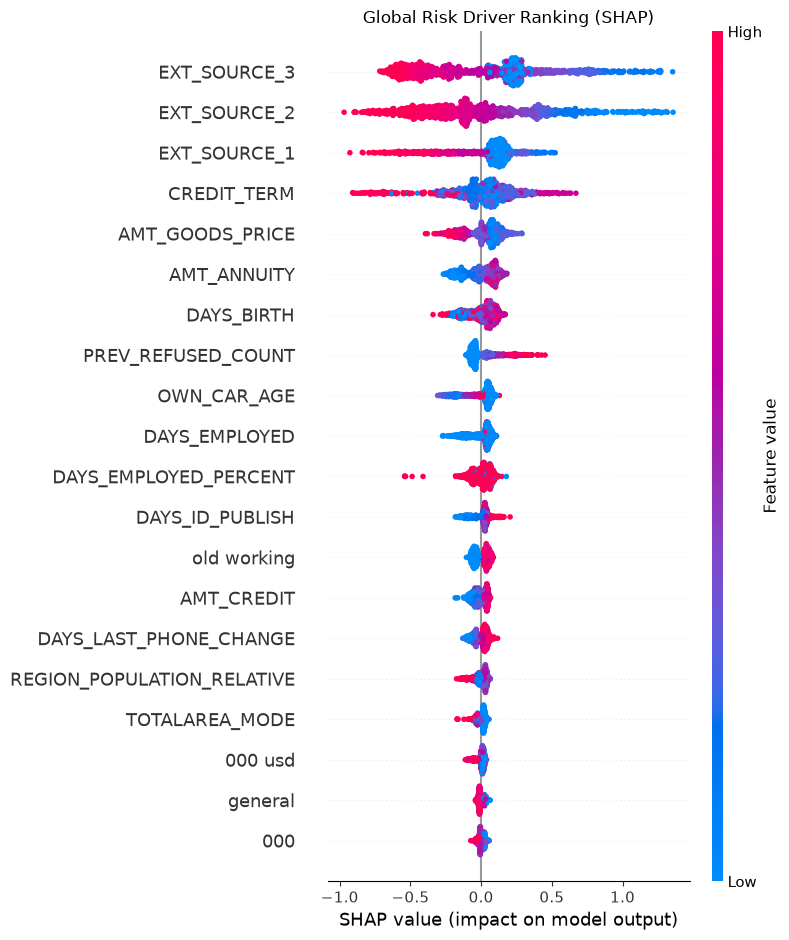

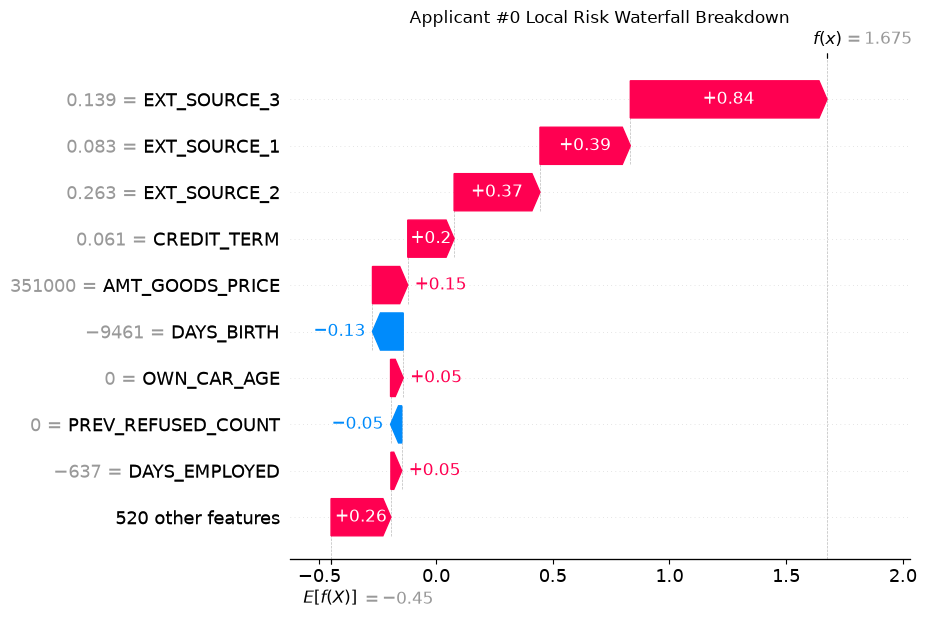

In [13]:
print("Retraining LightGBM on complete hybrid dataset...")
final_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    scale_pos_weight=11.3,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_hybrid, y)

feature_names = list(selected_num_cols) + list(tfidf.get_feature_names_out())
explainer = shap.TreeExplainer(final_model)

X_sample = X_hybrid[:1000].toarray()
shap_values = explainer(X_sample)

plt.figure(figsize=(10, 6))
plt.title("Global Risk Driver Ranking (SHAP)")
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Applicant #0 Local Risk Waterfall Breakdown")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[0],
        base_values=shap_values.base_values[0],
        data=X_sample[0],
        feature_names=feature_names
    ),
    max_display=10
)

In [ ]:
import os
os.makedirs('../app', exist_ok=True)

# Export models and column schema required by Streamlit
joblib.dump(tfidf, '../app/tfidf_vectorizer.pkl')
joblib.dump(final_model, '../app/lightgbm_model.pkl')
joblib.dump(selected_num_cols, '../app/feature_cols.pkl')

print("Pipeline artifacts successfully saved to ../app/:")
print(" - tfidf_vectorizer.pkl")
print(" - lightgbm_model.pkl")
print(" - feature_cols.pkl")

Pipeline artifacts successfully saved to ../app/:
 - tfidf_vectorizer.pkl
 - lightgbm_model.pkl
 - feature_cols.pkl


: 